<p style="margin:0 0 16px 0;">
  <a href="https://colab.research.google.com/github/adrishg/iDopa_featurization/blob/main/runiDopaBoltz2.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
  </a>
</p>

<table width="100%" style="border:0; border-collapse:collapse; table-layout:fixed; margin:0 0 18px 0;">
  <tr style="border:0;">
    <td style="border:0; vertical-align:middle; width:calc(100% - 190px); padding:18px 18px 18px 0; overflow-wrap:break-word; word-break:normal;">
      <h1 style="margin:0 0 12px 0; font-size:34px; line-height:1.12; font-weight:700;">iDopaSnFR Boltz2 Colab</h1>
      <p style="margin:0 0 8px 0; font-size:17px; line-height:1.35;"><b>Structure Ensemble featurization and prediction.</b></p>
      <p style="margin:0; font-size:15px; line-height:1.45;">Default setup runs dopamine and serotonin Boltz2 jobs, then summarizes confidence metrics and prepares repo-backed feature tables. Custom ligands and APO protein-only runs are optional.</p>
      <p style="margin:10px 0 0 0; font-size:14px; line-height:1.35;">APO is off by default. When enabled, APO writes a protein-only YAML, skips chain B, and does not request affinity.</p>
    </td>
    <td style="border:0; vertical-align:middle; text-align:right; width:190px; padding:18px 0 18px 10px;">
      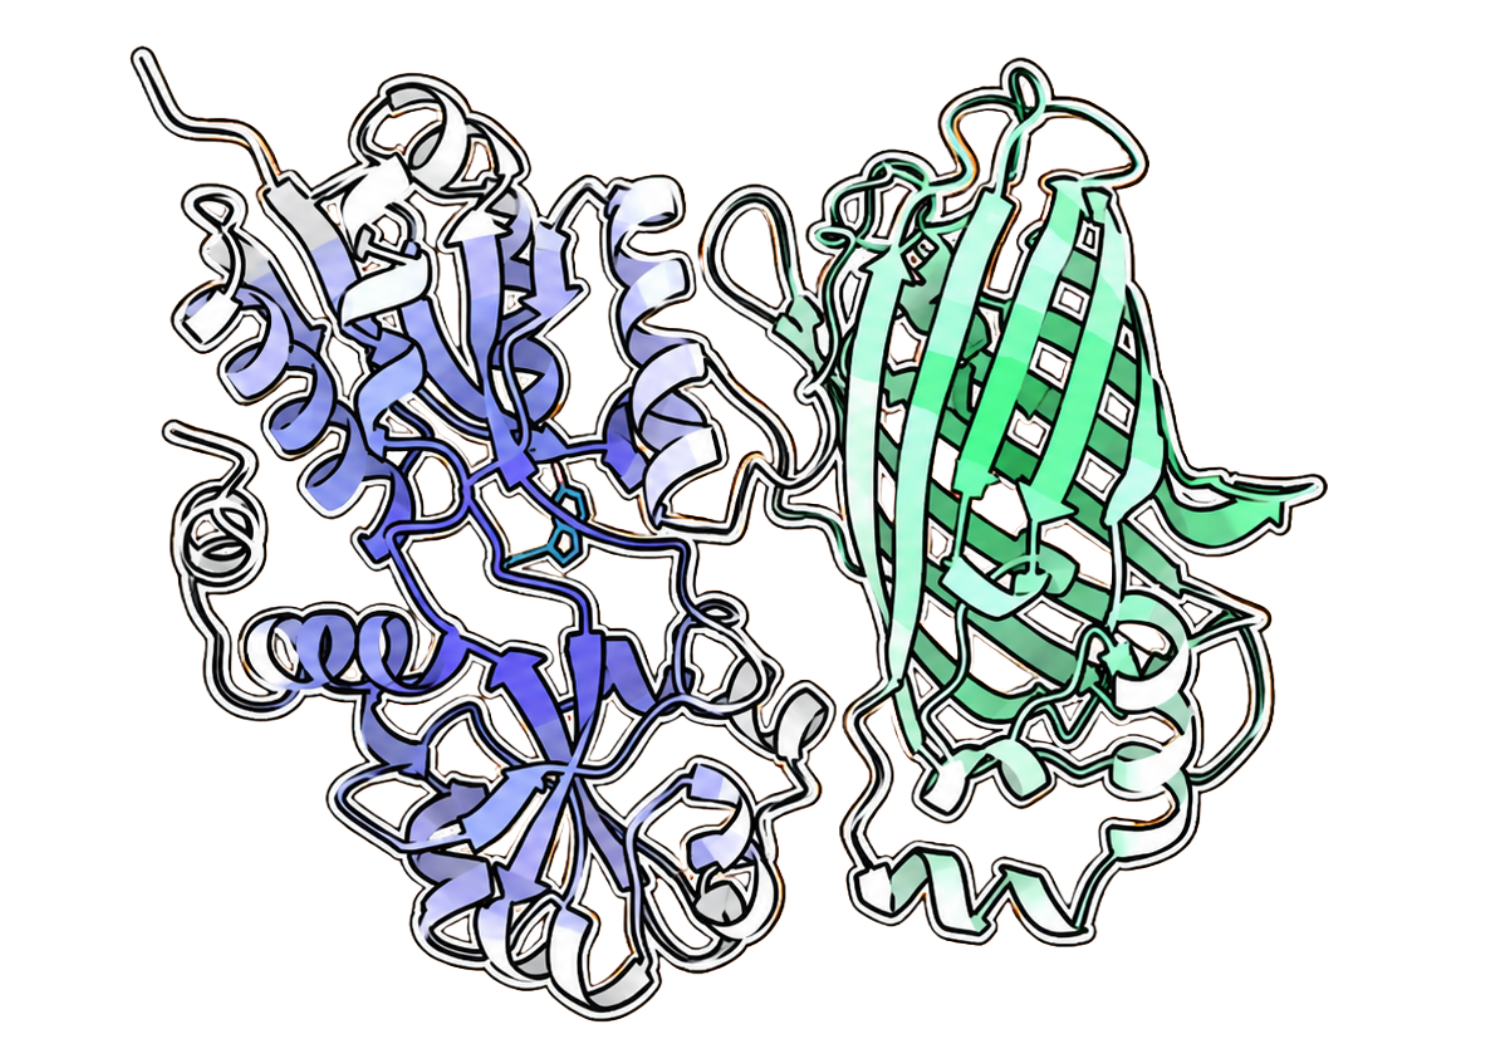
    </td>
  </tr>
</table>

Default run setup:

| default condition | label | ligand input |
|---|---|---|
| dopamine | `DOP` | `C1=CC(=C(C=C1CCN)O)O` |
| serotonin | `5HT` | `C1=CC2=C(C=C1O)C(=CN2)CCN` |

Optional run modes:

| optional condition | label | behavior |
|---|---|---|
| custom ligand | user label | adds one ligand chain from the provided SMILES and requests affinity |
| apo protein | `APO` | protein-only YAML, no chain B, no affinity request |

Notes:
- Default DOP and 5HT ligand runs include Boltz2 affinity arguments and an affinity property in the YAML.
- APO is off by default; enable `run_apo` only when you want a protein-only structure ensemble.
- Ligand feature extraction is skipped for APO because overlap and affinity features require a ligand.
- Feature extraction and prediction use the scripts and Structure Ensemble models stored in this repository.

In [ ]:
#@title 1. Input sequence, ligand choices, and Boltz2 settings
import os, re, json, glob, textwrap, subprocess, shutil
from pathlib import Path

# -------------------------
# Protein / variant input
# -------------------------
sequence_alias = "iDopaSnFR_0.7" #@param {type:"string"}
query_sequence = "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKRNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIADKQKNGIETNFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKNDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPLATDPAGAYETVKKEYKRKWNIVWLKPLGFNAGPSLAVKDELAKQYNLKTFSDLAKISDKLILGANMEFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLNILEDDKIFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI" #@param {type:"string"}
#@markdown Use `:` only if you intentionally want multiple protein chains.

# -------------------------
# Run input
# -------------------------
run_dopamine = True #@param {type:"boolean"}
run_serotonin = True #@param {type:"boolean"}
run_apo = False #@param {type:"boolean"}
custom_ligand_label = "" #@param {type:"string"}
custom_ligand_smiles = "" #@param {type:"string"}
#@markdown APO creates a protein-only YAML with no chain B and no affinity request.

MOLECULES = {
    "DOP": {"name": "dopamine", "smiles": "C1=CC(=C(C=C1CCN)O)O"},
    "5HT": {"name": "serotonin", "smiles": "C1=CC2=C(C=C1O)C(=CN2)CCN"},
}
APO_LABEL = "APO"
selected_ligands = []
if run_dopamine:
    selected_ligands.append("DOP")
if run_serotonin:
    selected_ligands.append("5HT")
if run_apo:
    selected_ligands.append(APO_LABEL)
if custom_ligand_label.strip() and custom_ligand_smiles.strip():
    label = re.sub(r"[^A-Za-z0-9_]+", "_", custom_ligand_label.strip())
    if label.upper() == APO_LABEL:
        raise ValueError("Use the run_apo checkbox for APO instead of a custom ligand named APO.")
    MOLECULES[label] = {"name": label, "smiles": custom_ligand_smiles.strip()}
    selected_ligands.append(label)

ligand_run_labels = [lig for lig in selected_ligands if lig != APO_LABEL]

# -------------------------
# Boltz2 settings
# -------------------------
job_prefix = "iDopaSnFR_boltz2" #@param {type:"string"}
diffusion_samples = 3 #@param {type:"integer"}
recycling_steps = 0 #@param {type:"integer"}
sampling_steps = 200 #@param {type:"integer"}
diffusion_samples_affinity = 5 #@param {type:"integer"}
sampling_steps_affinity = 200 #@param {type:"integer"}
max_parallel_samples = 5 #@param {type:"integer"}
use_msa_server = True #@param {type:"boolean"}
use_potentials = True #@param {type:"boolean"}
override_existing_predictions = True #@param {type:"boolean"}
output_format = "pdb" #@param ["mmcif", "pdb"]

# -------------------------
# Notebook folders
# -------------------------
base_dir = Path("/content") if Path("/content").exists() else Path.cwd()
work_dir = base_dir / "idopa_boltz2_runs"
yaml_dir = work_dir / "yamls"
out_dir = work_dir / "boltz_outputs"
analysis_dir = work_dir / "analysis"
for p in [work_dir, yaml_dir, out_dir, analysis_dir]:
    p.mkdir(parents=True, exist_ok=True)

query_sequence = "".join(query_sequence.split())
if not query_sequence or "PASTE_" in query_sequence:
    raise ValueError("Please paste the actual iDopaSnFR_0.7 sequence into query_sequence before running.")
if not selected_ligands:
    raise ValueError("Select at least one ligand, provide a custom ligand, or enable run_apo.")

clean_alias = re.sub(r"[^A-Za-z0-9_.-]+", "_", sequence_alias.strip())
print("Variant:", clean_alias)
print("Sequence length:", len(query_sequence.replace(':','')))
print("Runs:", selected_ligands)
print("Ligand runs with affinity:", ligand_run_labels if ligand_run_labels else "none")
print("Work dir:", work_dir)
print("Output format:", output_format)

In [ ]:
#@title 2. Install/check notebook dependencies {display-mode: "form"}
#@markdown Run this once before the analysis cells. This follows the working order: install/update Boltz first, then restore the NumPy/pandas pair used by the notebook.
import os, sys, subprocess
from pathlib import Path

PIP = [sys.executable, "-m", "pip"]

def run_pip(args, label):
    print(f"\n--- {label} ---")
    cmd = PIP + args
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)

# Install Boltz and notebook helpers first. Boltz may adjust compiled dependencies.
run_pip(["install", "-q", "-U", "boltz[cuda]", "py3Dmol", "pyyaml", "matplotlib", "seaborn", "plotly", "ipywidgets"],
        "Installing/updating Boltz2 and notebook helper packages")

# Restore a binary-compatible NumPy/pandas pair after Boltz is installed.
# Do not import numpy or pandas before this cell finishes.
run_pip(["install", "-q", "--force-reinstall", "numpy==2.0.2", "pandas==2.2.2"],
        "Restoring binary-compatible NumPy/pandas pair")

# iDopa featurization repo, used later for optional feature extraction/model prediction.
repo_dir = work_dir / "iDopa_featurization"
if not repo_dir.exists():
    subprocess.run(["git", "clone", "https://github.com/adrishg/iDopa_featurization.git", str(repo_dir)], check=False)
else:
    subprocess.run(["git", "-C", str(repo_dir), "pull"], check=False)

print("\nSetup complete.")
print("repo_dir:", repo_dir)
print("Next: run the import/validation cell below. Do not manually reload pandas/numpy.")

In [ ]:
#@title 2.1 Import core packages and validate versions {display-mode: "form"}
#@markdown This imports packages normally after setup. It intentionally does not reload packages.
import os, re, json, glob, textwrap, subprocess, shutil, shlex
from pathlib import Path
import numpy as np
import pandas as pd
import yaml

try:
    import boltz
    boltz_version = getattr(boltz, "__version__", "installed")
except Exception as e:
    boltz_version = f"import warning: {e}"

print("Core package versions:")
print("  numpy:", np.__version__)
print("  pandas:", pd.__version__)
print("  boltz:", boltz_version)

if np.__version__ != "2.0.2" or pd.__version__ != "2.2.2":
    print("WARNING: Expected numpy==2.0.2 and pandas==2.2.2 for this notebook setup.")
    print("If you imported pandas before setup, restart the runtime and run cells from the top.")
else:
    print("Environment looks consistent.")

In [ ]:
#@title 3. Build Boltz2 YAMLs
import yaml

protein_chain_id = "A"
ligand_chain_id = "B"

def build_boltz_yaml(sequence, run_label):
    yml = {
        "version": 1,
        "sequences": [
            {"protein": {"id": protein_chain_id, "sequence": sequence}},
        ],
    }
    if run_label != APO_LABEL:
        molecule = MOLECULES[run_label]
        yml["sequences"].append({"ligand": {"id": ligand_chain_id, "smiles": molecule["smiles"]}})
        yml["properties"] = [{"affinity": {"binder": ligand_chain_id}}]
    return yml

yaml_paths = {}
for run_label in selected_ligands:
    input_name = f"{clean_alias}_{run_label}"
    yml = build_boltz_yaml(query_sequence, run_label)
    yaml_path = yaml_dir / f"{input_name}.yaml"
    with open(yaml_path, "w") as f:
        yaml.safe_dump(yml, f, sort_keys=False)
    yaml_paths[run_label] = yaml_path
    kind = "protein-only APO" if run_label == APO_LABEL else f"ligand {run_label}"
    print(f"Wrote {kind}: {yaml_path}")

print("\nYAML preview:")
print(open(next(iter(yaml_paths.values()))).read())

In [ ]:
#@title 4. Run Boltz2 predictions
#@markdown Ligand runs request affinity. APO runs are protein-only and skip all affinity flags.
import shlex, subprocess, os

boltz_cache = work_dir / "boltz_cache"
boltz_cache.mkdir(parents=True, exist_ok=True)
os.environ["BOLTZ_CACHE"] = str(boltz_cache)

run_logs = {}
for run_label, yaml_path in yaml_paths.items():
    cmd = [
        "boltz", "predict", str(yaml_path),
        "--out_dir", str(out_dir),
        "--cache", str(boltz_cache),
        "--recycling_steps", str(recycling_steps),
        "--diffusion_samples", str(diffusion_samples),
        "--sampling_steps", str(sampling_steps),
        "--max_parallel_samples", str(max_parallel_samples),
        "--output_format", output_format,
    ]
    if run_label != APO_LABEL:
        cmd.extend([
            "--diffusion_samples_affinity", str(diffusion_samples_affinity),
            "--sampling_steps_affinity", str(sampling_steps_affinity),
        ])
    if use_msa_server:
        cmd.append("--use_msa_server")
    if use_potentials:
        cmd.append("--use_potentials")
    if override_existing_predictions:
        cmd.append("--override")

    print("\n===== Running", run_label, "=====")
    print(" ".join(shlex.quote(x) for x in cmd))
    log_path = analysis_dir / f"boltz_run_{run_label}.log"
    with open(log_path, "w") as log:
        proc = subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, text=True)
    run_logs[run_label] = {"returncode": proc.returncode, "log": str(log_path)}
    print(f"returncode={proc.returncode}; log={log_path}")
    if proc.returncode != 0:
        print(open(log_path).read()[-4000:])

run_logs

In [ ]:
#@title 5. Parse Boltz2 outputs and summarize top models
import json, glob, os, numpy as np, pandas as pd
from pathlib import Path


def find_prediction_dir(run_label):
    input_name = f"{clean_alias}_{run_label}"
    candidates = list(out_dir.glob(f"**/predictions/{input_name}")) + list(out_dir.glob(f"**/{input_name}"))
    candidates = [p for p in candidates if p.is_dir()]
    if not candidates:
        return None
    candidates.sort(key=lambda p: len(list(p.glob("*.cif"))) + len(list(p.glob("*.pdb"))), reverse=True)
    return candidates[0]


def read_json(path):
    with open(path) as f:
        return json.load(f)


def safe_get(d, key, default=np.nan):
    value = d.get(key, default) if isinstance(d, dict) else default
    if isinstance(value, (list, tuple, dict, np.ndarray)):
        return default
    return value

metrics_columns = [
    "ligand", "ligand_name", "run_type", "model_idx", "prediction_dir", "structure_file",
    "confidence_score", "complex_plddt", "iptm", "ligand_iptm", "protein_iptm", "ptm",
    "complex_iplddt", "mean_token_plddt_npz", "min_token_plddt_npz", "max_token_plddt_npz",
    "affinity_pred_value", "affinity_probability_binary", "affinity_pred_value1",
    "affinity_probability_binary1", "affinity_pred_value2", "affinity_probability_binary2", "status",
]

rows = []
prediction_dirs = {}
structure_files = {}

for run_label in selected_ligands:
    pred_dir = find_prediction_dir(run_label)
    prediction_dirs[run_label] = pred_dir
    if pred_dir is None:
        if run_label != APO_LABEL:
            rows.append({"ligand": run_label, "run_type": "ligand", "status": "prediction_folder_not_found"})
        continue

    input_name = f"{clean_alias}_{run_label}"
    conf_files = sorted(pred_dir.glob(f"confidence_{input_name}_model_*.json"))
    cif_files = sorted(pred_dir.glob(f"{input_name}_model_*.cif"))
    pdb_files = sorted(pred_dir.glob(f"{input_name}_model_*.pdb"))
    structure_files[run_label] = cif_files if cif_files else pdb_files

    if run_label == APO_LABEL:
        continue

    affinity = {}
    aff_files = list(pred_dir.glob(f"affinity_{input_name}.json")) + list(pred_dir.glob("affinity*.json"))
    affinity = read_json(aff_files[0]) if aff_files else {}

    for conf_path in conf_files:
        m = re.search(r"_model_(\d+)\.json$", conf_path.name)
        model_idx = int(m.group(1)) if m else None
        conf = read_json(conf_path)
        plddt_file = pred_dir / f"plddt_{input_name}_model_{model_idx}.npz"
        mean_token_plddt = np.nan
        min_token_plddt = np.nan
        max_token_plddt = np.nan
        if plddt_file.exists():
            try:
                dat = np.load(plddt_file)
                arr = dat[dat.files[0]]
                mean_token_plddt = float(np.nanmean(arr))
                min_token_plddt = float(np.nanmin(arr))
                max_token_plddt = float(np.nanmax(arr))
            except Exception:
                pass
        rows.append({
            "ligand": run_label,
            "ligand_name": "apo" if run_label == APO_LABEL else MOLECULES[run_label]["name"],
            "run_type": "apo" if run_label == APO_LABEL else "ligand",
            "model_idx": model_idx,
            "prediction_dir": str(pred_dir),
            "structure_file": str((pred_dir / f"{input_name}_model_{model_idx}.{ 'cif' if output_format == 'mmcif' else 'pdb'}")),
            "confidence_score": safe_get(conf, "confidence_score"),
            "complex_plddt": safe_get(conf, "complex_plddt"),
            "iptm": safe_get(conf, "iptm"),
            "ligand_iptm": safe_get(conf, "ligand_iptm"),
            "protein_iptm": safe_get(conf, "protein_iptm"),
            "ptm": safe_get(conf, "ptm"),
            "complex_iplddt": safe_get(conf, "complex_iplddt"),
            "mean_token_plddt_npz": mean_token_plddt,
            "min_token_plddt_npz": min_token_plddt,
            "max_token_plddt_npz": max_token_plddt,
            "affinity_pred_value": safe_get(affinity, "affinity_pred_value"),
            "affinity_probability_binary": safe_get(affinity, "affinity_probability_binary"),
            "affinity_pred_value1": safe_get(affinity, "affinity_pred_value1"),
            "affinity_probability_binary1": safe_get(affinity, "affinity_probability_binary1"),
            "affinity_pred_value2": safe_get(affinity, "affinity_pred_value2"),
            "affinity_probability_binary2": safe_get(affinity, "affinity_probability_binary2"),
            "status": "ok",
        })

metrics_df = pd.DataFrame.from_records(rows, columns=metrics_columns)
metrics_csv = analysis_dir / "boltz2_metrics_summary.csv"
metrics_df.to_csv(metrics_csv, index=False)
print("Saved:", metrics_csv)
if not metrics_df.empty:
    display(metrics_df.sort_values(["ligand", "confidence_score"], ascending=[True, False]).head(20))
else:
    print("No metrics were parsed. Check the Boltz logs above.")

In [ ]:
print('Unique ligands in metrics_df:', metrics_df['ligand'].unique())
display(metrics_df)

In [ ]:
#@title 7. Visualize Boltz2 confidence and affinity metrics
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ok = metrics_df[metrics_df["status"].eq("ok")].copy()
if ok.empty:
    print("No successful metrics yet. Run Boltz2 first and check logs.")
else:
    summary_cols = ["ligand", "run_type", "model_idx", "confidence_score", "complex_plddt", "iptm", "protein_iptm"]
    for optional_col in ["ligand_iptm", "affinity_pred_value", "affinity_probability_binary"]:
        if optional_col in ok.columns and ok[optional_col].notna().any():
            summary_cols.append(optional_col)
    top = ok.sort_values("confidence_score", ascending=False).groupby("ligand", as_index=False).head(1)
    display(top[summary_cols])

    metrics_to_plot = [
        "confidence_score",
        "complex_plddt",
        "iptm",
        "protein_iptm",
        "ligand_iptm",
        "affinity_pred_value",
        "affinity_probability_binary",
    ]
    available_metrics = [m for m in metrics_to_plot if m in ok.columns and ok[m].notna().any()]

    if not available_metrics:
        print("No numerical metrics with data available to plot distributions.")
    else:
        num_metrics = len(available_metrics)
        nrows, ncols = (num_metrics + 2) // 3, 3
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
        fig.suptitle('Distribution of Boltz2 Metrics by Run', fontsize=16)
        axes = axes.flatten()

        for i, metric in enumerate(available_metrics):
            ax = axes[i]
            sns.violinplot(data=ok, x="ligand", y=metric, hue="ligand", inner="quartile", palette="pastel", linewidth=1, ax=ax, legend=False)
            sns.stripplot(data=ok, x="ligand", y=metric, hue="ligand", jitter=0.2, palette="pastel", size=4, edgecolor="black", linewidth=0.7, alpha=0.8, ax=ax, dodge=True, legend=False)
            ax.set_title(metric, fontsize=12)
            ax.set_ylabel(metric, fontsize=10)
            ax.set_xlabel("Run", fontsize=10)
            ax.tick_params(axis='x', rotation=0)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [ ]:
#@title 7. Reference sequences and mutation annotation setup
#@markdown Choose a built-in iDopaSnFR reference, `none`, or `custom`.
#@markdown If `custom` is selected, paste the reference protein sequence below.
import pandas as pd, os, re, json

compare_to = "iDopaSnFR_0.5" #@param ["none", "iDopaSnFR_0.1", "iDopaSnFR_0.3", "iDopaSnFR_0.31", "iDopaSnFR_0.4", "iDopaSnFR_0.5", "iDopaSnFR_0.7", "iDopaSnFR_0.8", "custom"]
custom_reference_alias = "custom_reference" #@param {type:"string"}
custom_reference_sequence = "" #@param {type:"string"}

reference_csv_path = analysis_dir / "reference_sequences.csv"

references_df = pd.DataFrame(
[
    {"alias": "iDopaSnFR_0.1", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKLNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIADKQKNGIKANFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPGATDPAGAYETVKKEYKRKWNIVWLKPLGFNAPSSLAVKDELAKQYNLKTFSDLAKISDKLILGANMMFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDATATDGLLVSHKLKILEDDKAFFPPYYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},
    {"alias": "iDopaSnFR_0.3", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKLNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIADKQKNGIKANFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPGATDPAGAYETVKKEYKRKWNIVWLKPLGFNAGSSLAVKDELAKQYNLKTFSDLAKISDKLILGANMMFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLKILEDDKAFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},
    {"alias": "iDopaSnFR_0.31", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKRNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIAVKQKNGIEANFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPGATDPAGAYETVKKEYKRKWNIVWLKPLGFNAGSSLAVKDELAKQYNLKTFSDLAKISDKLILGANMMFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLNILEDDKAFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},
    {"alias": "iDopaSnFR_0.4", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKRNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIAVKQKNGIEANFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPGATDPAGAYETVKKEYKRKWNIVWLKPLGFNAGPSLAVKDELAKQYNLKTFSDLAKISDKLILGANMEFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLNILEDDKAFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},
    {"alias": "iDopaSnFR_0.5", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKRNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIAVKQKNGIEANFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKDDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPGATDPAGAYETVKKEYKRKWNIVWLKPLGFNAGPSLAVKDELAKQYNLKTFSDLAKISDKLILGANMEFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLNILEDDKIFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},
    {"alias": "iDopaSnFR_0.7", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKRNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIADKQKNGIETNFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLSTQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKNDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPLATDPAGAYETVKKEYKRKWNIVWLKPLGFNAGPSLAVKDELAKQYNLKTFSDLAKISDKLILGANMEFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLNILEDDKIFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},
    {"alias": "iDopaSnFR_0.8", "sequence": "ANDTVVVGSINHTEQIIVANMLAEMIEAHTDLKVVRKRNLGGVEVNFEAIKRGGANNGIDIYLEYVGYGLVDILGYPEPEVYIIADKQKNGIVTNFKIRYNVEDGSVQLADHYQQNTPIGDGPVLLPDTHYLITQSKLSKDPNEKRDHMVLLEFVTAAGITLGMDELYKGGTGGSMSKGEELFTGVVPILVELDGGVNGHKFSVRGEGEGDATNGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTISFKNDGTYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNFPPPLALDPAGAYETVKKEYKRKWNIVWLKPLGFNAGPSLAVKDELAKQYNLKTFSDLAKISDKLILGANMEFLENPDGYPGLQKRYNFKFKHTKSMDAGIPYTAIDNNEVQVIDAEATDGLLVSHKLNILEDDKIFFPPWYAAPIIRQDVLDKHPELKDVLNKLANQISLEEMQKLNYKRDGEGQDPAKVAKEFLKEKGLI", "annotations": ""},

])
references_df.to_csv(reference_csv_path, index=False)
display(references_df)
print("Reference CSV:", reference_csv_path)

AA3_TO_1 = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
    'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V',
    'SEC':'U','PYL':'O','ASX':'B','GLX':'Z','UNK':'X'
}

def normalize_sequence(seq):
    return re.sub(r"[^A-Za-z]", "", str(seq)).upper()

def get_reference_sequence(alias):
    m = references_df[references_df["alias"].astype(str).eq(alias)]
    if m.empty:
        return None
    seq = normalize_sequence(m.iloc[0]["sequence"])
    if not seq or "PASTE" in seq:
        return None
    return seq

query_seq_flat = normalize_sequence(query_sequence.replace(':',''))
ref_sequence = None
reference_label = None

if compare_to == "none":
    print("No reference comparison selected; mutation highlighting is disabled.")
elif compare_to == "custom":
    ref_sequence = normalize_sequence(custom_reference_sequence)
    reference_label = custom_reference_alias.strip() or "custom_reference"
    if not ref_sequence:
        print("Custom reference selected, but no sequence was provided; mutation highlighting is disabled.")
else:
    ref_sequence = get_reference_sequence(compare_to)
    reference_label = compare_to
    if ref_sequence is None:
        print(f"No usable reference sequence found for {compare_to}; mutation highlighting is disabled.")

mutations = []
if ref_sequence:
    for i, (r, q) in enumerate(zip(ref_sequence, query_seq_flat), start=1):
        if r != q:
            mutations.append({"pos": i, "ref": r, "query": q, "label": f"{r}{i}{q}"})
    if len(ref_sequence) != len(query_seq_flat):
        print(f"Warning: reference length {len(ref_sequence)} != query length {len(query_seq_flat)}. Mutation mapping is simple positional mapping only.")
    print("Comparing to:", reference_label)

mutations_df = pd.DataFrame(mutations, columns=["pos", "ref", "query", "label"])
display(mutations_df.head(50))
print("Number of differences vs reference:", len(mutations_df))


In [ ]:
#@title 8. Display 3D structure with ligand + mutation highlighting {run: "auto"}
import py3Dmol, glob, os, re, json
from pathlib import Path

ligand_to_display = "5HT" #@param ["DOP", "5HT", "APO"] {allow-input: true}
model_idx_to_display = 0 #@param {type:"integer"}
color_by = "pLDDT" #@param ["pLDDT", "chain", "rainbow", "white"]
protein_style = "cartoon" #@param ["cartoon", "line"]
show_ligand = True #@param {type:"boolean"}
ligand_representation = "sticks_and_spheres" #@param ["sticks_and_spheres", "sticks", "spheres", "none"]
show_mutations_vs_reference = True #@param {type:"boolean"}
residue_representation = "sticks_and_spheres" #@param ["sticks_and_spheres", "sticks", "spheres", "none"]
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}
spin = False #@param {type:"boolean"}

if ligand_to_display not in selected_ligands:
    ligand_to_display = selected_ligands[0]
if ligand_to_display == APO_LABEL:
    show_ligand = False

input_name = f"{clean_alias}_{ligand_to_display}"
pred_dir = prediction_dirs.get(ligand_to_display) or find_prediction_dir(ligand_to_display)
if pred_dir is None:
    raise FileNotFoundError(f"No prediction folder found for {ligand_to_display}.")

candidates = list(pred_dir.glob(f"{input_name}_model_{model_idx_to_display}.cif")) + list(pred_dir.glob(f"{input_name}_model_{model_idx_to_display}.pdb"))
if not candidates:
    candidates = sorted(pred_dir.glob(f"{input_name}_model_*.cif")) + sorted(pred_dir.glob(f"{input_name}_model_*.pdb"))
    if not candidates:
        raise FileNotFoundError(f"No structure files found in {pred_dir}")
structure_path = candidates[0]
fmt = "cif" if structure_path.suffix.lower() == ".cif" else "pdb"
print("Displaying:", structure_path)

view = py3Dmol.view(width=900, height=650, js='https://3dmol.org/build/3Dmol.js')
view.addModel(open(structure_path).read(), fmt)

protein_sel = {"chain": protein_chain_id}
if color_by == "pLDDT":
    style = {protein_style: {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 0.5, "max": 1.0}}}
elif color_by == "rainbow":
    style = {protein_style: {"color": "spectrum"}}
elif color_by == "chain":
    style = {protein_style: {"color": "lightblue"}}
else:
    style = {protein_style: {"color": "white"}}
view.setStyle(protein_sel, style)

if show_mainchains:
    view.addStyle({"chain": protein_chain_id, "atom": ["N","CA","C","O"]}, {"stick": {"radius": 0.18, "color": "white"}})
if show_sidechains:
    view.addStyle({"chain": protein_chain_id, "atom": ["N","CA","C","O"], "invert": True}, {"stick": {"radius": 0.22, "colorscheme": "WhiteCarbon"}})

if show_ligand and ligand_representation != "none" and ligand_to_display != APO_LABEL:
    lig_sel = {"chain": ligand_chain_id}
    if ligand_representation in ["sticks", "sticks_and_spheres"]:
        view.addStyle(lig_sel, {"stick": {"radius": 0.28, "colorscheme": "greenCarbon"}})
    if ligand_representation in ["spheres", "sticks_and_spheres"]:
        view.addStyle(lig_sel, {"sphere": {"scale": 0.28, "colorscheme": "greenCarbon"}})

if show_mutations_vs_reference and len(mutations) > 0 and residue_representation != "none":
    for mut in mutations:
        sel = {"chain": protein_chain_id, "resi": int(mut["pos"])}
        if residue_representation in ["sticks", "sticks_and_spheres"]:
            view.addStyle(sel, {"stick": {"radius": 0.35, "color": "magenta"}})
        if residue_representation in ["spheres", "sticks_and_spheres"]:
            view.addStyle(sel, {"sphere": {"scale": 0.45, "color": "magenta"}})
        view.addLabel(mut["label"], {"fontSize": 10, "fontColor": "black", "backgroundColor": "white", "backgroundOpacity": 0.75}, sel)

view.zoomTo()
if spin:
    view.spin(True)
view.show()

row = metrics_df[(metrics_df["ligand"].eq(ligand_to_display)) & (metrics_df["model_idx"].eq(model_idx_to_display))]
if not row.empty:
    display_cols = ["ligand", "run_type", "model_idx", "confidence_score", "complex_plddt", "iptm", "protein_iptm"]
    for optional_col in ["ligand_iptm", "affinity_pred_value", "affinity_probability_binary"]:
        if optional_col in row.columns and row[optional_col].notna().any():
            display_cols.append(optional_col)
    display(row[display_cols])
else:
    print("No metrics row found for displayed model.")

In [ ]:
#@title 9. Optional: run iDopa featurization scripts on the new Boltz2 outputs
#@markdown Ligand feature extraction runs for ligand predictions only. APO is kept in the Boltz summary but skipped here because there is no ligand overlap or affinity.
run_repo_feature_extraction = False #@param {type:"boolean"}
run_repo_affinity_parser = False #@param {type:"boolean"}
run_existing_ml_models = False #@param {type:"boolean"}
model_folder_or_file = "" #@param {type:"string"}

import shlex, subprocess, os, shutil
from pathlib import Path

repo_dir = Path(globals().get("repo_dir", work_dir / "iDopa_featurization"))
featurization_dir = repo_dir / "featurization"
analysis_script = repo_dir / "analysis.sh"

needs_repo_tools = run_repo_feature_extraction or run_repo_affinity_parser or run_existing_ml_models
if needs_repo_tools:
    if not repo_dir.exists():
        raise FileNotFoundError(f"Repository folder not found: {repo_dir}. Run the setup cell first.")
    if not featurization_dir.exists():
        raise FileNotFoundError(f"Featurization script folder not found: {featurization_dir}. Pull the latest GitHub repo version or check the repository layout.")

    print("Repo dir:", repo_dir)
    print("Featurization dir:", featurization_dir)
    print("Featurization scripts:")
    for p in sorted(featurization_dir.glob("*.py")):
        print(" -", p.name)
else:
    print("Featurization is off; skipping repo feature scripts.")

manifest = {
    "sequence_alias": clean_alias,
    "sequence": query_sequence,
    "runs": selected_ligands,
    "ligand_runs": ligand_run_labels,
    "yaml_dir": str(yaml_dir),
    "out_dir": str(out_dir),
    "analysis_dir": str(analysis_dir),
    "metrics_csv": str(metrics_csv),
}
manifest_path = analysis_dir / "idopa_new_variant_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)
print("Wrote manifest:", manifest_path)

if run_repo_affinity_parser:
    script = featurization_dir / "getAffinities.py"
    if script.exists():
        print("\nFound getAffinities.py. Inspect help for arguments:")
        subprocess.run(["python", str(script), "--help"], check=False)
        print("\nAffinity parsing is only valid for ligand runs, not APO.")
    else:
        print("getAffinities.py not found in featurization folder.")

if run_repo_feature_extraction:
    if not analysis_script.exists():
        raise FileNotFoundError(f"analysis.sh not found: {analysis_script}")

    if not ligand_run_labels:
        print("No ligand runs selected. Skipping ligand featurization for APO-only run.")

    for lig in ligand_run_labels:
        ligand_analysis_output_path = analysis_dir / lig
        ligand_analysis_output_path.mkdir(parents=True, exist_ok=True)

        boltz_pred_dir = prediction_dirs.get(lig)
        if not boltz_pred_dir or not boltz_pred_dir.exists():
            print(f"Warning: Boltz2 prediction directory not found for {lig}. Skipping analysis.sh for {lig}.")
            continue

        model_0_cif = boltz_pred_dir / f"{clean_alias}_{lig}_model_0.cif"
        model_0_pdb = boltz_pred_dir / f"{clean_alias}_{lig}_model_0.pdb"
        if model_0_cif.exists():
            reference_target_path = boltz_pred_dir / "reference.cif"
            shutil.copy(model_0_cif, reference_target_path)
            print(f"Copied {model_0_cif.name} to {reference_target_path.name} in {boltz_pred_dir}/")
        elif model_0_pdb.exists():
            reference_target_path = boltz_pred_dir / "reference.pdb"
            shutil.copy(model_0_pdb, reference_target_path)
            print(f"Copied {model_0_pdb.name} to {reference_target_path.name} in {boltz_pred_dir}/")
        else:
            print(f"Warning: model_0 structure file not found for {lig} at {boltz_pred_dir}. Continuing without reference copy.")

        print(f"\n===== Running {analysis_script.name} for {lig} =====")
        cmd = ["bash", str(analysis_script), str(boltz_pred_dir.parent), str(ligand_analysis_output_path)]
        print("Command:", " ".join(shlex.quote(x) for x in cmd))

        proc = subprocess.run(cmd, capture_output=True, text=True, check=False)
        print(f"Return Code: {proc.returncode}")
        if proc.stdout:
            print("Stdout:\n", proc.stdout)
        if proc.stderr:
            print("Stderr:\n", proc.stderr)
        if proc.returncode != 0:
            print(f"Error running {analysis_script.name} for {lig}. Check logs above.")

    for script_name in ["batch_LigOverlapVol.py", "batch_distanceMaps_variance.py", "getOpenessDistances.py", "getOpenessDistancesProp.py"]:
        script = featurization_dir / script_name
        if script.exists():
            print(f"\n===== Help for {script_name} ====")
            subprocess.run(["python", str(script), "--help"], check=False)

if run_existing_ml_models:
    if not model_folder_or_file:
        print("Provide model_folder_or_file first.")
    else:
        print("Model prediction placeholder. Add the exact loader once model filenames/classes are fixed.")
        print("Input metrics file:", metrics_csv)
        print("Model path:", model_folder_or_file)

In [ ]:
#@title 9.1 Assemble model-ready feature table (optional) {display-mode: "form"}
import pandas as pd
import numpy as np
from pathlib import Path

if not globals().get("run_repo_feature_extraction", False):
    final_features_df = pd.DataFrame()
    features_to_display = pd.DataFrame()
    print("Skipping model-ready feature table because feature extraction is off.")
else:
    # Ensure access to variables from previous cells
    # work_dir, analysis_dir, clean_alias, ligand_run_labels, metrics_df

    # Initialize the final DataFrame with the 'Tag' column (variant alias)
    final_features_df = pd.DataFrame({'Tag': [clean_alias]})

    # Dictionary to map generic column names from the analysis CSVs
    # to the ligand-specific requested output names.
    # This assumes `volumes_variances_affinities_openess_clean.csv` contains these base names.
    column_mapping = {
        'overlap_volume': 'overlap_volume',
        'overlap_w_pos_volume': 'overlap_w_pos_volume',
        'overlap_w_neg_volume': 'overlap_w_neg_volume',
        'variance_avg': 'variance_avg',
        'variance_pLDDT_w': 'variance_pLDDT_w',
        'complex_PDE_avg': 'complex_PDE_avg',
        'complex_PDE_var': 'complex_PDE_var',
        'complex_PDE_min': 'complex_PDE_min',
        'complex_PDE_max': 'complex_PDE_max',
        'PAE_avg': 'PAE_avg',
        'PDE_avg': 'PDE_avg',
        'openess_avg': 'openess_avg',
        'openess_min': 'openess_min',
        'openess_max': 'openess_max',
        'openess_range': 'openess_range'
        # affinity and pLDDT will be handled slightly differently due to multiple versions/sources
    }

    for lig in ligand_run_labels:
        # Path to the generated clean CSV for each ligand
        csv_path = analysis_dir / lig / "volumes_variances_affinities_openess_clean.csv"

        lig_data = {'Tag': clean_alias}
        lig_prefix = lig # 'DOP' or '5HT'

        # Add Folder_Path
        lig_data[f"Folder_Path_{lig_prefix}"] = str(analysis_dir / lig_prefix)

        if csv_path.exists():
            df_lig_analysis = pd.read_csv(csv_path)

            # Filter for the current variant's data (assuming 'Tag' column exists in the CSV)
            # If the CSV has multiple rows per tag (e.g., models), take the first or aggregate
            variant_row = df_lig_analysis[df_lig_analysis['Tag'] == clean_alias].iloc[0] if 'Tag' in df_lig_analysis.columns and clean_alias in df_lig_analysis['Tag'].values else (df_lig_analysis.iloc[0] if not df_lig_analysis.empty else None)

            if variant_row is not None:
                for generic_col, target_base_name in column_mapping.items():
                    output_col_name = f"{target_base_name}_{lig_prefix}"
                    if generic_col in variant_row.index:
                        lig_data[output_col_name] = variant_row[generic_col]
                    else:
                        lig_data[output_col_name] = np.nan

                # Extract pLDDT and affinity from metrics_df for the top model (model_idx=0)
                top_model_metrics = metrics_df[(metrics_df['ligand'] == lig) & (metrics_df['model_idx'] == 0)]
                if not top_model_metrics.empty:
                    top_model_metrics = top_model_metrics.iloc[0]
                    lig_data[f"ligand_pLDDT_avg_{lig_prefix}"] = top_model_metrics.get('complex_plddt', np.nan) # Boltz reports complex_plddt as average
                    lig_data[f"ligand_pLDDT_min_{lig_prefix}"] = top_model_metrics.get('min_token_plddt_npz', np.nan)
                    lig_data[f"ligand_pLDDT_max_{lig_prefix}"] = top_model_metrics.get('max_token_plddt_npz', np.nan)

                    # Affinity values - using the generic affinity values as requested (non-v1)
                    lig_data[f"affinity_pred_value_{lig_prefix}"] = top_model_metrics.get('affinity_pred_value', np.nan)
                    lig_data[f"affinity_probability_binary_{lig_prefix}"] = top_model_metrics.get('affinity_probability_binary', np.nan)
                else:
                    print(f"Warning: No top model metrics found for {lig}.")

            else:
                print(f"Warning: Variant '{clean_alias}' data not found in {csv_path}")
        else:
            print(f"Warning: Clean CSV not found for {lig} at {csv_path}")

        # Convert lig_data to a DataFrame and merge
        final_features_df = final_features_df.merge(pd.DataFrame([lig_data]), on='Tag', how='left')

    # Add the generic 'Ligand' column
    final_features_df['Ligand'] = clean_alias

    # Calculate combined metrics (only if both ligands are present)
    if '5HT' in ligand_run_labels and 'DOP' in ligand_run_labels:
        final_features_df['average_pLDDT_5HT/DOP'] = (
            final_features_df[f'ligand_pLDDT_avg_5HT'].fillna(0) +
            final_features_df[f'ligand_pLDDT_avg_DOP'].fillna(0)
        ) / 2
        final_features_df['ligand_pLDDT_min_5HT/DOP'] = final_features_df[[f'ligand_pLDDT_min_5HT', f'ligand_pLDDT_min_DOP']].min(axis=1)
        final_features_df['ligand_pLDDT_max_5HT/DOP'] = final_features_df[[f'ligand_pLDDT_max_5HT', f'ligand_pLDDT_max_DOP']].max(axis=1)
        final_features_df['affinity_probability_5HT/DOP'] = (
            final_features_df[f'affinity_probability_binary_5HT'].fillna(0) + # Updated to non-v1
            final_features_df[f'affinity_probability_binary_DOP'].fillna(0)  # Updated to non-v1
        ) / 2
        final_features_df['affinity_probability_binary_5HT/DOP'] = (
            final_features_df[f'affinity_probability_binary_5HT'].fillna(0) + # Updated to non-v1
            final_features_df[f'affinity_probability_binary_DOP'].fillna(0)  # Updated to non-v1
        ) / 2 # Assuming same calculation as probability for now
    else:
        final_features_df['average_pLDDT_5HT/DOP'] = np.nan
        final_features_df['ligand_pLDDT_min_5HT/DOP'] = np.nan
        final_features_df['ligand_pLDDT_max_5HT/DOP'] = np.nan
        final_features_df['affinity_probability_5HT/DOP'] = np.nan
        final_features_df['affinity_probability_binary_5HT/DOP'] = np.nan


    # Define the exact order of columns as requested by the user
    output_columns = [
        'Tag', 'Folder_Path_5HT', 'overlap_volume_5HT', 'overlap_w_pos_volume_5HT', 'overlap_w_neg_volume_5HT',
        'ligand_pLDDT_avg_5HT', 'ligand_pLDDT_min_5HT', 'ligand_pLDDT_max_5HT',
        'variance_avg_5HT', 'variance_pLDDT_w_5HT', 'complex_PDE_avg_5HT', 'complex_PDE_var_5HT',
        'complex_PDE_min_5HT', 'complex_PDE_max_5HT', 'PAE_avg_5HT', 'PDE_avg_5HT',
        'affinity_pred_value_5HT', 'affinity_probability_binary_5HT', # Updated to non-v1
        'openess_avg_5HT', 'openess_min_5HT', 'openess_max_5HT', 'openess_range_5HT',
        'Ligand', 'Folder_Path_DOP', 'overlap_volume_DOP', 'overlap_w_pos_volume_DOP', 'overlap_w_neg_volume_DOP',
        'ligand_pLDDT_avg_DOP', 'ligand_pLDDT_min_DOP', 'ligand_pLDDT_max_DOP',
        'variance_avg_DOP', 'variance_pLDDT_w_DOP', 'complex_PDE_avg_DOP', 'complex_PDE_var_DOP',
        'complex_PDE_min_DOP', 'complex_PDE_max_DOP', 'PAE_avg_DOP', 'PDE_avg_DOP',
        'affinity_pred_value_DOP', 'affinity_probability_binary_DOP', # Updated to non-v1
        'openess_avg_DOP', 'openess_min_DOP', 'openess_max_DOP', 'openess_range_DOP',
        'average_pLDDT_5HT/DOP', 'ligand_pLDDT_min_5HT/DOP', 'ligand_pLDDT_max_5HT/DOP',
        'affinity_probability_5HT/DOP', 'affinity_probability_binary_5HT/DOP'
    ]

    # Create the final DataFrame, ensuring all requested columns are present and in order.
    # Fill any missing columns with NaN.
    features_to_display = pd.DataFrame(columns=output_columns)
    for col in output_columns:
        if col in final_features_df.columns:
            features_to_display[col] = final_features_df[col]
        else:
            features_to_display[col] = np.nan

    # Display the DataFrame
    display(features_to_display)


In [ ]:
#Here need to add connection to model to predict

In [ ]:
#@title 10. Package notebook outputs for download
import zipfile, glob, os
from google.colab import files

zip_path = work_dir / f"{clean_alias}_boltz2_idopa_results.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [yaml_dir, analysis_dir]:
        for path in folder.rglob("*"):
            if path.is_file():
                z.write(path, path.relative_to(work_dir))
    # Include structures and JSON/NPZ outputs without the huge processed cache.
    for path in out_dir.rglob("*"):
        if path.is_file() and any(path.suffix.lower() == ext for ext in [".cif", ".pdb", ".json", ".npz", ".csv", ".yaml"]):
            z.write(path, path.relative_to(work_dir))

print("Created:", zip_path)
files.download(str(zip_path))